In [355]:
# Import the needed libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, train_test_split

In [356]:
randome_state = 13

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

In [357]:
# Read the dataset
breast_cancer_dataset = pd.read_csv('../data/breast_cancer/wdbc.data')
# Set column names (needed since the data file doesn't have a header row)
breast_cancer_dataset.columns = [
    'ID',
    'Diagnosis',
    'radius1',
    'texture1',
    'perimeter1',
    'area1',
    'smoothness1',
    'compactness1',
    'concavity1',
    'concave_points1',
    'symmetry1',
    'fractal_dimensions1',
    'radius2',
    'texture2',
    'perimeter2',
    'area2',
    'smoothness2',
    'compactness2',
    'concavity2',
    'concave_points2',
    'symmetry2',
    'fractal_dimensions2',
    'radius3',
    'texture3',
    'perimeter3',
    'area3',
    'smoothness3',
    'compactness3',
    'concavity3',
    'concave_points3',
    'symmetry3',
    'fractal_dimensions3',
]
# Show the first 5 rows to validate that the data import has been successful
breast_cancer_dataset.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimensions1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimensions2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [358]:
breast_cancer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   568 non-null    int64  
 1   Diagnosis            568 non-null    object 
 2   radius1              568 non-null    float64
 3   texture1             568 non-null    float64
 4   perimeter1           568 non-null    float64
 5   area1                568 non-null    float64
 6   smoothness1          568 non-null    float64
 7   compactness1         568 non-null    float64
 8   concavity1           568 non-null    float64
 9   concave_points1      568 non-null    float64
 10  symmetry1            568 non-null    float64
 11  fractal_dimensions1  568 non-null    float64
 12  radius2              568 non-null    float64
 13  texture2             568 non-null    float64
 14  perimeter2           568 non-null    float64
 15  area2                568 non-null    flo

In [359]:
# Remove the ID column since this has no predictive value
breast_cancer_dataset = breast_cancer_dataset.drop('ID', axis=1)

# Separate the dataset into features (inputs) and targets (output/ground truth)
features = breast_cancer_dataset.drop('Diagnosis', axis=1)
targets = breast_cancer_dataset['Diagnosis']

In [360]:
# Mean normalization using pandas
features_normalized = (features - features.mean())/features.std()

In [361]:
targets.value_counts()

Diagnosis
B    357
M    211
Name: count, dtype: int64

In [362]:
targets_encoded = pd.Series(LabelEncoder().fit_transform(targets))
np.unique_counts(targets_encoded)

UniqueCountsResult(values=array([0, 1]), counts=array([357, 211]))

In [363]:
# The training and tuning setup above will produce different 
# results with each new run due to random effects

# The simplest way to handle this is to use a fixed random state. However, 
# this will make it impossible to confidently conclude which model performs 
# the best

global_random_state = 13

# The data splitting is random and needs the global seed

train_indices = breast_cancer_dataset.groupby('Diagnosis').sample(frac=0.6, random_state=global_random_state).index
train_features = features_normalized.iloc[train_indices]
train_targets = targets_encoded.iloc[train_indices]

testvalidation_dataset = breast_cancer_dataset.drop(train_indices, axis=0)
validation_indices = testvalidation_dataset.groupby('Diagnosis').sample(frac=0.5, random_state=global_random_state).index

validation_features = features_normalized.iloc[validation_indices]
validation_targets = targets_encoded.iloc[validation_indices]

test_indices = testvalidation_dataset.drop(validation_indices, axis=0).index
test_features = features_normalized.iloc[test_indices]
test_targets = targets_encoded.iloc[test_indices]

# The model also needs the global random seed, though this isn't always used 
# internally (depends on model type and the hyperparameters specified)
dt_default = DecisionTreeClassifier(random_state=global_random_state)
 
# A better approach would be to run multiple times to calculate the mean and 
# standard deviation

In [391]:
# Create functions to perform evaluation 

# Used to evaluate hyperparameter tuning
def validation(model):
    train_predictions = model.predict(train_features)
    validation_predictions = model.predict(validation_features)
    print(f'Training Accuracy: {accuracy_score(train_targets, train_predictions):.2f} Validation: {accuracy_score(validation_targets, validation_predictions):.2f}')    
    print(f'Training Precision: {precision_score(train_targets, train_predictions):.2f} Validation: {precision_score(validation_targets, validation_predictions):.2f}')    
    print(f'Training Recall: {recall_score(train_targets, train_predictions):.2f} Validation: {recall_score(validation_targets, validation_predictions):.2f}')    
    print(f'Training F1: {f1_score(train_targets, train_predictions):.2f} Validation: {f1_score(validation_targets, validation_predictions):.2f}')    

# Used for final testing
def test(model):
    train_predictions = model.predict(train_features)
    validation_predictions = model.predict(validation_features)
    test_predictions = model.predict(test_features)
    print(f'Training Accuracy: {accuracy_score(train_targets, train_predictions):.2f} Validation: {accuracy_score(validation_targets, validation_predictions):.2f} Testing: {accuracy_score(test_targets, test_predictions):.2f}')  
    print(f'Training Precision: {precision_score(train_targets, train_predictions):.2f} Validation: {precision_score(validation_targets, validation_predictions):.2f} Testing: {precision_score(test_targets, test_predictions):.2f}')    
    print(f'Training Recall: {recall_score(train_targets, train_predictions):.2f} Validation: {recall_score(validation_targets, validation_predictions):.2f} Testing: {recall_score(test_targets, test_predictions):.2f}')    
    print(f'Training F1: {f1_score(train_targets, train_predictions):.2f} Validation: {f1_score(validation_targets, validation_predictions):.4f} Testing: {f1_score(test_targets, test_predictions):.4f}')    


In [365]:
# Train a decision tree with default hyperparameters
dt_default = DecisionTreeClassifier()
dt_default.fit(train_features, train_targets)
# Perform validation
test(dt_default)


Training Accuracy: 1.00 Validation: 0.93 Testing: 0.92
Training Precision: 1.00 Validation: 0.87 Testing: 0.90
Training Recall: 1.00 Validation: 0.95 Testing: 0.88
Training F1: 1.00 Validation: 0.91 Testing: 0.89


In [366]:
# Tune max_depth hyperparameter

# Start with max_depth=3
dt_maxdepth_3 = DecisionTreeClassifier(max_depth=3)
dt_maxdepth_3.fit(train_features, train_targets)
test(dt_maxdepth_3)

Training Accuracy: 0.98 Validation: 0.91 Testing: 0.91
Training Precision: 0.98 Validation: 0.85 Testing: 0.85
Training Recall: 0.97 Validation: 0.93 Testing: 0.93
Training F1: 0.98 Validation: 0.89 Testing: 0.89


## Create a default naive bayes classifier

In [367]:
default_nb = GaussianNB()
default_nb.fit(train_features, train_targets)
validation(default_nb)

Training Accuracy: 0.94 Validation: 0.94
Training Precision: 0.93 Validation: 0.91
Training Recall: 0.91 Validation: 0.93
Training F1: 0.92 Validation: 0.92


In [368]:
nb_smoothing_1 = GaussianNB(var_smoothing=1e-5)
nb_smoothing_1.fit(train_features, train_targets)
test(nb_smoothing_1)

Training Accuracy: 0.94 Validation: 0.94 Testing: 0.93
Training Precision: 0.93 Validation: 0.91 Testing: 0.90
Training Recall: 0.91 Validation: 0.93 Testing: 0.90
Training F1: 0.92 Validation: 0.92 Testing: 0.90


In [369]:
# Final testing of the best model
validation(dt_maxdepth_3)

Training Accuracy: 0.98 Validation: 0.91
Training Precision: 0.98 Validation: 0.85
Training Recall: 0.97 Validation: 0.93
Training F1: 0.98 Validation: 0.89


## HGB

In [370]:
hgb_default = HistGradientBoostingClassifier(random_state=global_random_state)
hgb_300 = HistGradientBoostingClassifier(random_state=global_random_state, max_iter=300)

In [371]:
hgb_default.fit(train_features, train_targets)
validation(hgb_default)

Training Accuracy: 1.00 Validation: 0.95
Training Precision: 1.00 Validation: 0.95
Training Recall: 1.00 Validation: 0.90
Training F1: 1.00 Validation: 0.93


In [372]:
hgb_300.fit(train_features, train_targets)
validation(hgb_300)

Training Accuracy: 1.00 Validation: 0.95
Training Precision: 1.00 Validation: 0.95
Training Recall: 1.00 Validation: 0.90
Training F1: 1.00 Validation: 0.93


In [373]:
print("DecisionTree max_depth=3")
test(dt_maxdepth_3)
print("GaussianNB")
test(default_nb)
print("HistGradientBoostingClassifier")
test(hgb_default)
print("HistGradientBoostingClassifier 300")
test(hgb_300)

DecisionTree max_depth=3
Training Accuracy: 0.98 Validation: 0.91 Testing: 0.91
Training Precision: 0.98 Validation: 0.85 Testing: 0.85
Training Recall: 0.97 Validation: 0.93 Testing: 0.93
Training F1: 0.98 Validation: 0.89 Testing: 0.89
GaussianNB
Training Accuracy: 0.94 Validation: 0.94 Testing: 0.93
Training Precision: 0.93 Validation: 0.91 Testing: 0.90
Training Recall: 0.91 Validation: 0.93 Testing: 0.90
Training F1: 0.92 Validation: 0.92 Testing: 0.90
HistGradientBoostingClassifier
Training Accuracy: 1.00 Validation: 0.95 Testing: 0.93
Training Precision: 1.00 Validation: 0.95 Testing: 0.89
Training Recall: 1.00 Validation: 0.90 Testing: 0.93
Training F1: 1.00 Validation: 0.93 Testing: 0.91
HistGradientBoostingClassifier 300
Training Accuracy: 1.00 Validation: 0.95 Testing: 0.94
Training Precision: 1.00 Validation: 0.95 Testing: 0.89
Training Recall: 1.00 Validation: 0.90 Testing: 0.95
Training F1: 1.00 Validation: 0.93 Testing: 0.92


In [374]:
def show_confusion(model):
    predictions = model.predict(test_features)
    print(confusion_matrix(test_targets, predictions))

In [375]:
def show_confusion_display(model):
    ConfusionMatrixDisplay.from_estimator(model, test_features, test_targets)

In [376]:
show_confusion(dt_maxdepth_3)

[[64  7]
 [ 3 39]]


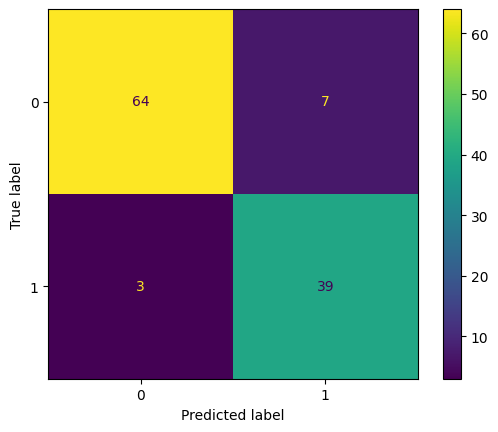

In [377]:
show_confusion_display(dt_maxdepth_3)

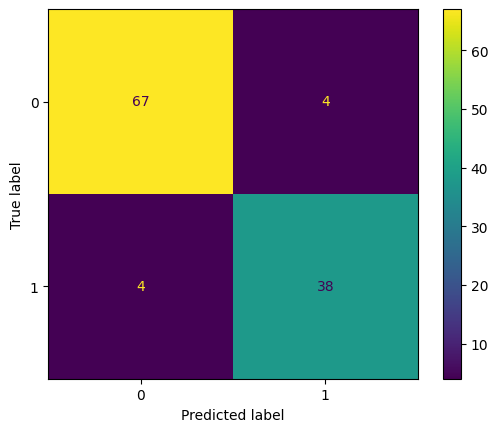

In [378]:
show_confusion_display(default_nb)

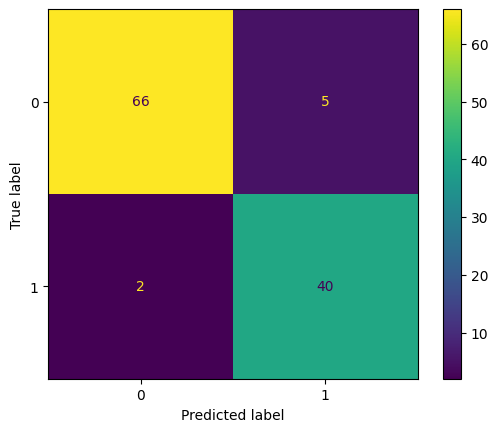

In [379]:
show_confusion_display(hgb_300)

In [380]:
def show_precisionrecall(model):
    PrecisionRecallDisplay.from_estimator(model, test_features, test_targets)

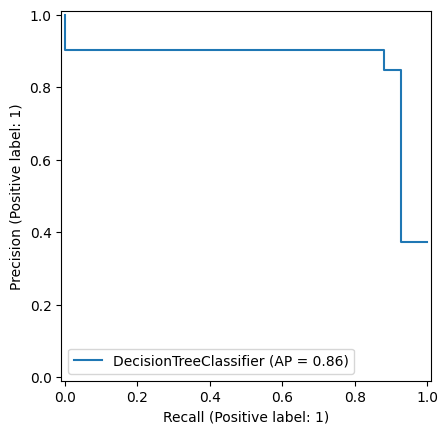

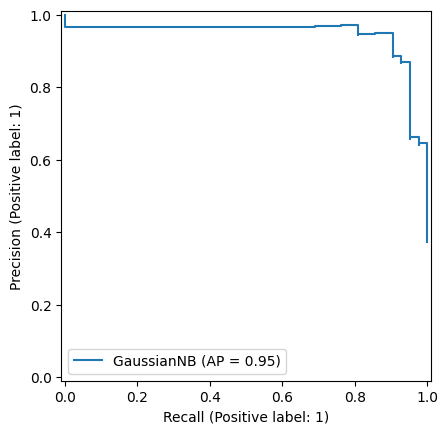

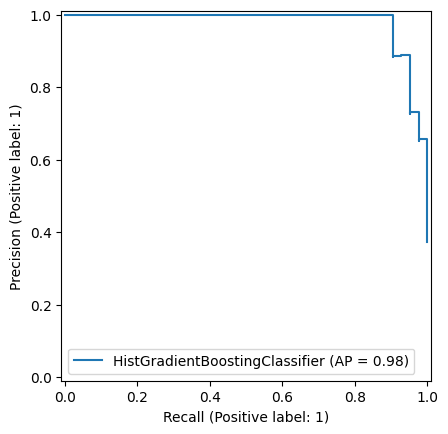

In [381]:
show_precisionrecall(dt_maxdepth_3)
show_precisionrecall(default_nb)
show_precisionrecall(hgb_300)

In [382]:
def nested_cv(model, param_grid, X, y):
    inner_cv = StratifiedKFold(5, shuffle=True, random_state=42)
    outer_cv = StratifiedKFold(5, shuffle=True, random_state=42)

    scores = []
    best_params = []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        search = GridSearchCV(model, param_grid, cv=inner_cv, scoring="f1")
        search.fit(X_train, y_train)

        scores.append(search.score(X_test, y_test))
        best_params.append(search.best_params_)

    return scores, best_params

In [383]:
model = HistGradientBoostingClassifier()

param_grid = {
    "max_iter": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1]
}

scores, best_params = nested_cv(model, param_grid, features, targets_encoded)
print(scores)
print(best_params)

[0.9438202247191011, 0.963855421686747, 0.9761904761904762, 0.9647058823529412, 0.95]
[{'learning_rate': 0.05, 'max_iter': 100}, {'learning_rate': 0.1, 'max_iter': 200}, {'learning_rate': 0.05, 'max_iter': 200}, {'learning_rate': 0.05, 'max_iter': 300}, {'learning_rate': 0.05, 'max_iter': 300}]


In [389]:
param_grid_2 = {
    "max_iter": [300],
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [5, 10, 15]
}

scores_2, best_params_2 = nested_cv(model, param_grid_2, features, targets_encoded)
print(scores_2)
print(best_params_2)

[0.9655172413793104, 0.963855421686747, 0.9761904761904762, 0.9647058823529412, 0.95]
[{'learning_rate': 0.03, 'max_depth': 10, 'max_iter': 300}, {'learning_rate': 0.08, 'max_depth': 5, 'max_iter': 300}, {'learning_rate': 0.08, 'max_depth': 5, 'max_iter': 300}, {'learning_rate': 0.08, 'max_depth': 5, 'max_iter': 300}, {'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 300}]


In [384]:
print(scores)

[0.9438202247191011, 0.963855421686747, 0.9761904761904762, 0.9647058823529412, 0.95]


In [385]:
X_train, X_test, y_train, y_test = train_test_split(features, targets_encoded, test_size=0.2, random_state=42)

In [386]:
best_model = HistGradientBoostingClassifier(random_state=global_random_state, max_iter=300, learning_rate=0.05)
best_model.fit(X_train, y_train)
y_train_pred = best_model.predict(X_train)
y_pred = best_model.predict(X_test)

In [393]:
print(f'Training Accuracy: {accuracy_score(y_train, y_train_pred):.2f} Testing: {accuracy_score(y_test, y_pred):.2f}')  
print(f'Training Precision: {precision_score(y_train, y_train_pred):.2f} Testing: {precision_score(y_test, y_pred):.2f}')    
print(f'Training Recall: {recall_score(y_train, y_train_pred):.2f} Testing: {recall_score(y_test, y_pred):.2f}')    
print(f'Training F1: {f1_score(y_train, y_train_pred):.2f} Testing: {f1_score(y_test, y_pred):.4f}')    


Training Accuracy: 1.00 Testing: 0.96
Training Precision: 1.00 Testing: 0.98
Training Recall: 1.00 Testing: 0.91
Training F1: 1.00 Testing: 0.9438


In [396]:
best_model_2 = HistGradientBoostingClassifier(random_state=global_random_state, max_iter=300, learning_rate=0.03, max_depth=10)
best_model_2.fit(X_train, y_train)
y_train_pred_2 = best_model_2.predict(X_train)
y_pred_2 = best_model_2.predict(X_test)

In [397]:
print(f'Training Accuracy: {accuracy_score(y_train, y_train_pred_2):.2f} Testing: {accuracy_score(y_test, y_pred_2):.2f}')  
print(f'Training Precision: {precision_score(y_train, y_train_pred_2):.2f} Testing: {precision_score(y_test, y_pred_2):.2f}')    
print(f'Training Recall: {recall_score(y_train, y_train_pred_2):.2f} Testing: {recall_score(y_test, y_pred_2):.2f}')    
print(f'Training F1: {f1_score(y_train, y_train_pred_2):.2f} Testing: {f1_score(y_test, y_pred_2):.4f}')    


Training Accuracy: 1.00 Testing: 0.96
Training Precision: 1.00 Testing: 0.98
Training Recall: 1.00 Testing: 0.91
Training F1: 1.00 Testing: 0.9438


In [392]:
nb_smoothing_2 = GaussianNB(var_smoothing=1e-1)
nb_smoothing_2.fit(train_features, train_targets)
test(nb_smoothing_2)

Training Accuracy: 0.94 Validation: 0.92 Testing: 0.96
Training Precision: 0.96 Validation: 0.90 Testing: 0.97
Training Recall: 0.87 Validation: 0.88 Testing: 0.90
Training F1: 0.91 Validation: 0.8916 Testing: 0.9383


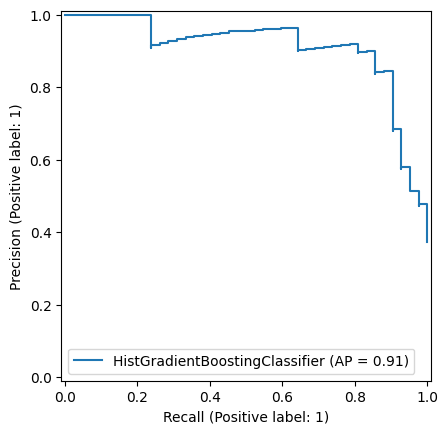

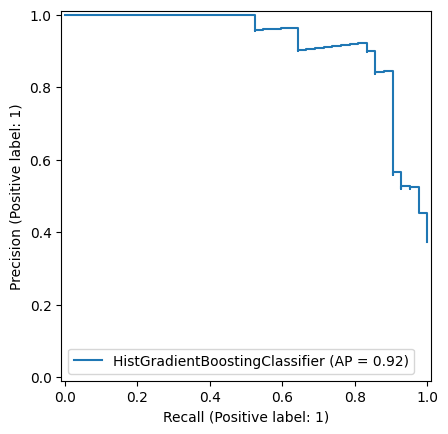

In [399]:
show_precisionrecall(best_model)
show_precisionrecall(best_model_2)